# 第 5 章 · 图搜索代码实验

完整讲解请看章节网页；这里只保留同一案例的可执行 Python 代码。

配套交互演示：[章节网页](../ch5.html)

## 本节目标

- 加载校园图数据
- 运行 BFS、DFS、UCS、Greedy、A*
- 查看路径、代价并与章节网页结果校验

## 1. 准备数据

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch05"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
from search_algorithms import *

In [2]:
graph = load_graph()

In [3]:
adj = build_adjacency(graph['edges'])

In [4]:
print('start:', graph['start'], 'goal:', graph['goal'])

start: x goal: c1


In [5]:
display(graph_summary())

,节点,名称,h(到操场)
6,c1,操场,0
1,c2,超市,1
2,j,教学楼,4
4,s1,食堂,3
3,s2,实验楼,4
5,t,图书馆,2
0,x,校门口,7


In [6]:
display(edges_table())

,边,代价
0,x↔c2,7
1,x↔j,2
2,x↔s1,2
3,j↔s2,4
4,s2↔s1,1
5,s1↔t,3
6,s1↔c1,6
7,t↔c1,2


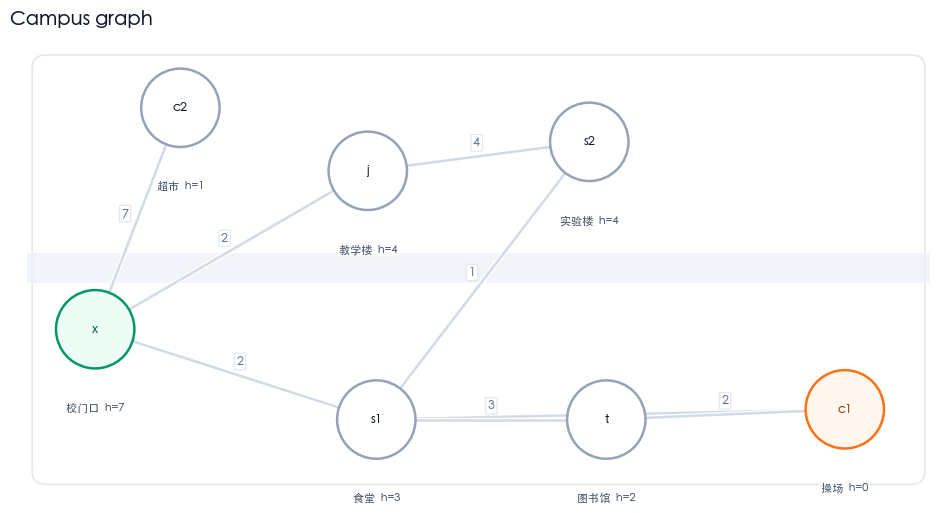

In [7]:
plot_campus(title='Campus graph')

## 2. 运行所有算法

In [8]:
results = run_all(graph)

In [9]:
display(comparison_table(graph))

,算法,路径,步数,代价,与网页
0,DFS,x→j→s2→s1→c1,4,13,✓
1,BFS,x→s1→c1,2,8,✓
2,UCS,x→s1→t→c1,3,7,✓
3,Greedy,x→s1→c1,2,8,✓
4,A*,x→s1→t→c1,3,7,✓


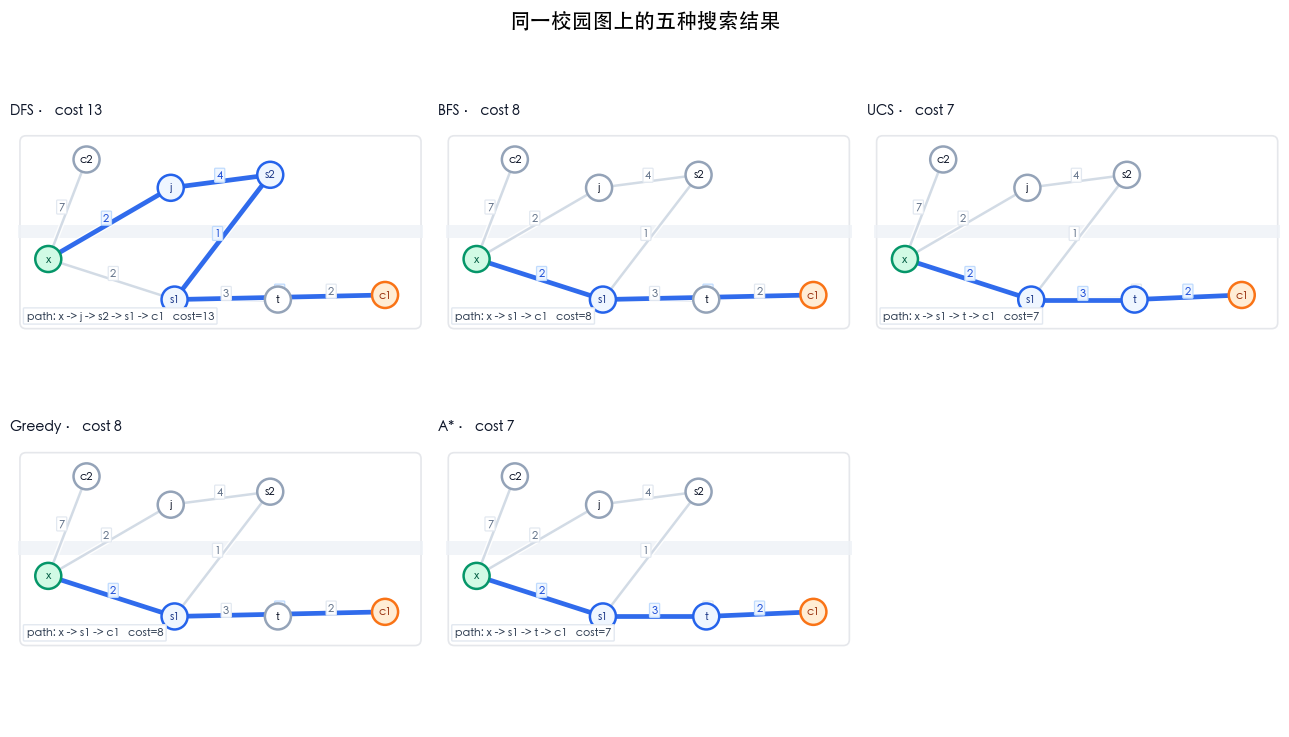

In [10]:
plot_all_paths(graph)

## 3. 单独运行一个算法

修改 `algo` 的值即可重跑其它算法：`bfs`、`dfs`、`ucs`、`greedy`、`astar`。

In [11]:
algo = 'astar'

In [12]:
path = results[algo]['path']

In [13]:
cost = path_cost(path, adj)

In [14]:
print(algo, 'path:', ' -> '.join(path), 'cost:', cost)

astar path: x -> s1 -> t -> c1 cost: 7


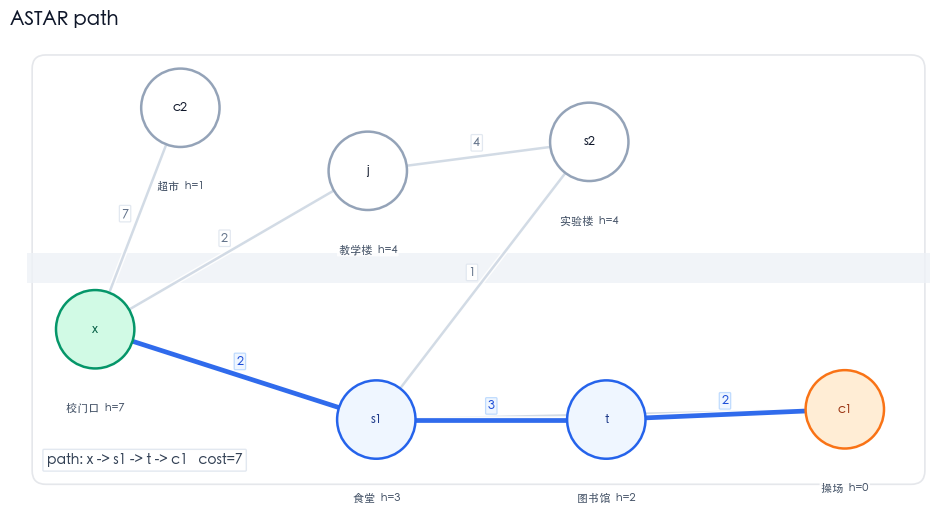

In [15]:
plot_campus(path, title=f'{algo.upper()} path')

## 4. 校验

In [16]:
verify_against_web(graph)

✓ 五种算法路径与 ch5.html 完全一致
